In [ ]:
# Necessary for successfully running on remote gpu
!pip install torch pandas transformers datasets peft scikit-learn tqdm accelerate huggingface_hub
!pip uninstall -y torchao
!pip install torchao==0.6.1 transformers==4.45.0
!pip install --upgrade --force-reinstall torch --index-url https://download.pytorch.org/whl/cu118

In [4]:
# Imports
import torch
import pandas as pd

from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from datasets import Dataset
import random, numpy as np

from transformers import AutoModelForCausalLM, BitsAndBytesConfig,DataCollatorForSeq2Seq
from peft import prepare_model_for_kbit_training
from peft import LoraConfig, get_peft_model
import matplotlib.pyplot as plt
from transformers import DataCollatorForLanguageModeling, TrainingArguments, Trainer,EarlyStoppingCallback
from sklearn.metrics import accuracy_score, f1_score, classification_report

import re
from tqdm import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [5]:
import os
import getpass
from huggingface_hub import login

# Verify GPU availability
print("--- Hardware Check ---")

is_cuda = torch.cuda.is_available()
print(f"CUDA available: {is_cuda}")

if is_cuda:
    print(f"Used GPU: {torch.cuda.get_device_name(0)}")


# Hugging Face login
print("\n--- Hugging Face Authentication ---")

if "HF_TOKEN" not in os.environ:
    hf_token = getpass.getpass("Enter your Hugging Face Access Token: ")
    login(token=hf_token, add_to_git_credential=True)
    os.environ["HF_TOKEN"] = hf_token
else:
    print("Hugging Face token already set in environment.")

--- Hardware Check ---
CUDA available: True
Used GPU: NVIDIA H100 80GB HBM3 MIG 4g.40gb

--- Hugging Face Authentication ---


Enter your Hugging Face Access Token:  ········


Token has not been saved to git credential helper.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


# Step 1
Next token prediction on the ISCO Manual

In [6]:
# Load the ISCO-08 Level 3 occupation descriptions
df_isco = pd.read_csv("../data/isco_level3.csv")

def add_code_to_prompt(row):
    """Combine ISCO code and description into a single text for continued pretraining."""
    return f"ISCO Code: {row['isco_code']}\n\n{row['prompt_text']}"

# Create the full text used for next-token prediction in Step 1
df_isco["full_text"] = df_isco.apply(add_code_to_prompt, axis=1)

In [7]:
# Load the base model tokenizer
BASE_MODEL_NAME = "meta-llama/Llama-3.1-8B"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)

# Use the EOS token as the padding token if no padding token is defined
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [8]:
def build_forward(row):
    """Create a code-to-description training example."""
    return f"ISCO Code: {row['isco_code']}\nDescription: {row['prompt_text']}{tokenizer.eos_token}"


def build_backward(row):
    """Create a description-to-code training example."""
    return f"Description: {row['prompt_text']}\n\nISCO Code: {row['isco_code']}{tokenizer.eos_token}"


# Create forward training examples: code -> description
df_forward = df_isco.copy()
df_forward["full_text"] = df_forward.apply(build_forward, axis=1)

# Create backward training examples: description -> code
df_backward = df_isco.copy()
df_backward["full_text"] = df_backward.apply(build_backward, axis=1)

# Combine both training directions into one dataset
df_combined = pd.concat([df_forward, df_backward], ignore_index=True)

print(f"Combined dataset: {len(df_combined)} rows (original: {len(df_isco)} rows)")

Combined dataset: 260 rows (original: 130 rows)


In [9]:
# Split the dataset into training and evaluation sets
train_df_isco, eval_df_isco = train_test_split(
    df_combined,
    test_size=0.10,
    random_state=SEED,
)

print(f"Train: {len(train_df_isco)} rows")
print(f"Eval:  {len(eval_df_isco)} rows")

Train: 234 rows
Eval:  26 rows


In [10]:
def tokenize_examples(examples):
    """Tokenize the training examples for next-token prediction."""
    return tokenizer(
        examples["full_text"],
        truncation=True,
        max_length=512,
        padding="do_not_pad",
    )

In [11]:
train_dataset_isco = Dataset.from_pandas(
    train_df_isco[["full_text"]].reset_index(drop=True)
)

eval_dataset_isco = Dataset.from_pandas(
    eval_df_isco[["full_text"]].reset_index(drop=True)
)

print(train_dataset_isco)
print(eval_dataset_isco)

Dataset({
    features: ['full_text'],
    num_rows: 234
})
Dataset({
    features: ['full_text'],
    num_rows: 26
})


In [12]:
# Tokenize the training and evaluation datasets
train_dataset_isco = train_dataset_isco.map(
    tokenize_examples,
    batched=True,
    remove_columns=["full_text"],
)

eval_dataset_isco = eval_dataset_isco.map(
    tokenize_examples,
    batched=True,
    remove_columns=["full_text"],
)

print(train_dataset_isco)
print(train_dataset_isco[0].keys())

Map:   0%|          | 0/234 [00:00<?, ? examples/s]

Map:   0%|          | 0/26 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 234
})
dict_keys(['input_ids', 'attention_mask'])


In [13]:
# Load the base causal language model
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

# Disable the KV cache during training
model.config.use_cache = False

# Check if the Step-1 adapter already exists
# If it exists, skip training and load the existing adapter
ADAPTER1_DIR = "isco_step1_adapter"
SKIP_TRAINING_STEP1 = os.path.isdir(ADAPTER1_DIR)

if SKIP_TRAINING_STEP1:
    print(f"Step-1 adapter found at {ADAPTER1_DIR} -> skipping training and loading the adapter.")
else:
    print("No Step-1 adapter found -> starting a new training run.")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Step-1 adapter found at isco_step1_adapter -> skipping training and loading the adapter.


In [14]:
# Install the required torchao version
!pip install -q -U "torchao>=0.16.0"

if SKIP_TRAINING_STEP1:
    # Load the already trained Step-1 adapter
    from peft import PeftModel
    model = PeftModel.from_pretrained(model, ADAPTER1_DIR)
    print(f"Pretrained Step-1 adapter loaded: {ADAPTER1_DIR}")
else:
    # Configure LoRA for causal language model training
    lora_config = LoraConfig(
        r=8,
        lora_alpha=32,
        lora_dropout=0.1,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=[
            "q_proj",
            "k_proj",
            "v_proj",
            "o_proj",
            "gate_proj",
            "up_proj",
            "down_proj",
        ],
    )

    # Apply LoRA to the base model
    model = get_peft_model(model, lora_config)

    # Show the number of trainable parameters
    model.print_trainable_parameters()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Pretrained Step-1 adapter loaded: isco_step1_adapter


In [15]:
if not SKIP_TRAINING_STEP1:
    # Install TensorBoard for logging training metrics
    !pip install tensorboard

In [16]:
if not SKIP_TRAINING_STEP1:
    # Create the data collator for causal language modeling
    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=False,
    )

    # Configure the training arguments
    training_args = TrainingArguments(
        output_dir="isco_step1_output",
        num_train_epochs=8,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=1e-4,
        warmup_steps=15,
        weight_decay=0.05,
        lr_scheduler_type="cosine",
        logging_steps=5,
        eval_strategy="steps",
        eval_steps=10,
        save_strategy="steps",
        save_steps=10,
        save_total_limit=2,
        bf16=True,
        report_to="tensorboard",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        seed=SEED,
    )

    # Initialize the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset_isco,
        eval_dataset=eval_dataset_isco,
        data_collator=data_collator,
        callbacks=[
            EarlyStoppingCallback(early_stopping_patience=3),
        ],
    )


In [17]:
if not SKIP_TRAINING_STEP1:
    # Train the model
    train_result = trainer.train()
else:
    print("Step-1 training skipped because the adapter already exists.")

Step-1 training skipped because the adapter already exists.


Training history loaded from isco_step1_adapter/train_history.json.


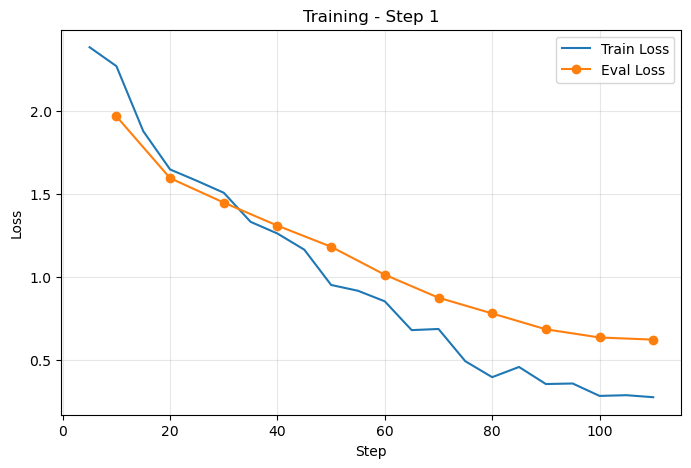

In [18]:
import json
import glob

def load_log_history_from_checkpoints(output_dir):
    """Load the log history from the latest Trainer checkpoint if train_history.json is missing.

    Each checkpoint folder contains a trainer_state.json file with the
    training history collected up to that point.
    """
    checkpoints = glob.glob(os.path.join(output_dir, "checkpoint-*"))
    if not checkpoints:
        return None

    latest = max(checkpoints, key=lambda p: int(p.rsplit("-", 1)[-1]))
    state_path = os.path.join(latest, "trainer_state.json")

    if not os.path.isfile(state_path):
        return None

    with open(state_path) as f:
        state = json.load(f)

    return state.get("log_history")


HISTORY_PATH_STEP1 = f"{ADAPTER1_DIR}/train_history.json"

if not SKIP_TRAINING_STEP1:
    # Freshly trained -> use the history directly from the Trainer
    history = trainer.state.log_history

elif os.path.isfile(HISTORY_PATH_STEP1):
    # Existing adapter loaded -> use the previously saved training history
    with open(HISTORY_PATH_STEP1) as f:
        history = json.load(f)

    print(f"Training history loaded from {HISTORY_PATH_STEP1}.")

else:
    # No train_history.json found -> reconstruct the history from the
    # original Trainer output directory and its checkpoints
    history = load_log_history_from_checkpoints("isco_step1_output")

    if history is not None:
        print(
            "Training history reconstructed from the Trainer checkpoints "
            "in 'isco_step1_output'."
        )

        # Save the history with the adapter for future use
        with open(HISTORY_PATH_STEP1, "w") as f:
            json.dump(history, f)

        print(
            f"-> Saved as {HISTORY_PATH_STEP1} so it can be loaded directly next time."
        )
    else:
        print(
            f"No training history found (neither {HISTORY_PATH_STEP1} "
            "nor checkpoints in 'isco_step1_output') -> skipping the plot."
        )

if history:
    # Extract training and evaluation loss
    train_loss = [
        (entry["step"], entry["loss"])
        for entry in history
        if "loss" in entry
    ]

    eval_loss = [
        (entry["step"], entry["eval_loss"])
        for entry in history
        if "eval_loss" in entry
    ]

    # Plot the training and evaluation loss
    plt.figure(figsize=(8, 5))

    if train_loss:
        train_steps, train_values = zip(*train_loss)
        plt.plot(train_steps, train_values, label="Train Loss")

    if eval_loss:
        eval_steps, eval_values = zip(*eval_loss)
        plt.plot(eval_steps, eval_values, label="Eval Loss", marker="o")

    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Training - Step 1")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [19]:
if not SKIP_TRAINING_STEP1:
    # Save the trained LoRA adapter and tokenizer
    model.save_pretrained(ADAPTER1_DIR)
    tokenizer.save_pretrained(ADAPTER1_DIR)

    # Save the training history so that the loss plot can be reproduced
    # later even when the adapter is only loaded and not retrained.
    import json
    with open(f"{ADAPTER1_DIR}/train_history.json", "w") as f:
        json.dump(trainer.state.log_history, f)

    print(f"Adapter and training history saved to {ADAPTER1_DIR}.")
else:
    print(f"Adapter already exists at {ADAPTER1_DIR} -> no need to save again.")

Adapter already exists at isco_step1_adapter -> no need to save again.


## Sanity Check
Check whether the model is able to generate sensible text.

In [20]:
# Set the model to evaluation mode
model.eval()


def generate_completion(prompt: str, max_new_tokens: int = 100):
    """Generate a deterministic completion for a given prompt."""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            repetition_penalty=1.2,
            pad_token_id=tokenizer.eos_token_id,
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)

In [21]:
# Test the model with an ISCO code prompt
prompt = "ISCO Code: 111\n\n"

print(generate_completion(prompt))

Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)


ISCO Code: 111

Description: Major group:
Managers

Sub-major group:
Chief Executives, Senior Officials and Legislators

Minor group:
Legislators and Senior Officialsg

Definition:
Legislators and senior officials determine or formulate policies of national, state, regional or local governments or communities; advise on, develop and implement plans for the economic, social and cultural activities of such government departments and agencies, public administrative and professional bodies, trade unions and similar organizations. They represent their organization in negotiations with respect


In [22]:
# Test the model with a partially completed ISCO hierarchy
prompt = "ISCO Code: 121\nMajor Group: Managers\nSub-Major Group:"

print(generate_completion(prompt))

ISCO Code: 121
Major Group: Managers
Sub-Major Group: Chief Executives, Senior Officials and Legislators

Minor Group:
Legislators and Senior Officialsp>

Definition:
Legislators and senior officials determine or formulate policies, plan, direct, organize and coordinate the activities of governments, parliaments, political parties, trade unions and similar organizations.

Tasks include:
Tasks performed usually include: presiding over sittings of parliament; debating and voting on issues in relation to government policy; representing a constituency as member of parliament; formulating advice and making


In [23]:
# Test the model by predicting an ISCO code from its definition
prompt = (
    "Definition: Legislators and senior officials determine, formulate, advise on "
    "and direct the implementation of policies of national, state, regional or "
    "local governments or communities, and of special interest organizations.\n\n"
    "ISCO Code:"
)

print(generate_completion(prompt, max_new_tokens=10))

Definition: Legislators and senior officials determine, formulate, advise on and direct the implementation of policies of national, state, regional or local governments or communities, and of special interest organizations.

ISCO Code: 121

Description:
Legislators and senior


In [24]:
# Test the model with an empty ISCO code prompt
prompt = "ISCO Code:"

print(generate_completion(prompt, max_new_tokens=5))

ISCO Code: 512
Description:


In [25]:
# Clear memory after Step 1 before starting Step 2
import gc

try:
    del trainer
    print("Step 1 trainer deleted.")
except NameError:
    print("No trainer object found. It may have already been deleted.")


gc.collect()
torch.cuda.empty_cache()

print("VRAM cleared after Step 1.")
print(f"Currently allocated VRAM: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

No trainer object found. It may have already been deleted.
VRAM cleared after Step 1.
Currently allocated VRAM: 16.18 GB


# Step 2
Instruction Fine-Tuning

In [26]:
# Set up logging for run metrics

import csv
import os


def log_run(metrics, path="run_log.csv"):
    """Append run metrics to a CSV file."""
    file_exists = os.path.isfile(path)

    with open(path, "a", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=metrics.keys())

        if not file_exists:
            writer.writeheader()

        writer.writerow(metrics)

    print(f"Metrics successfully saved to {path}.")

In [27]:
# Experiment settings
RUN_NAME = "run_final42"
USE_STEP1 = True
LORA_R = 8
LORA_ALPHA = 16
LEARNING_RATE = 1e-4
NUM_EPOCHS = 8

# Check if the adapter already exists
ADAPTER_DIR = f"./isco_step2_adapter_{RUN_NAME}"
SKIP_TRAINING = os.path.isdir(ADAPTER_DIR)

if SKIP_TRAINING:
    print(f"Adapter found at {ADAPTER_DIR} -> skipping training.")
else:
    print(f"No adapter found -> starting training.")

Adapter found at ./isco_step2_adapter_run_final42 -> skipping training.


In [28]:
# Load the labeled training data
df_labeled = pd.read_csv("../data/labeled.csv")

In [29]:
# Ensure the tokenizer has a padding token and uses right-side padding
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"


def build_instruction(row):
    """Create an instruction prompt for ISCO-08 classification."""
    return (
        "### Instruction:\n"
        "Classify the following job advertisement according to ISCO-08 "
        "(3-digit minor group code).\n\n"
        f"### Job Ad Title:\n{row['title']}\n\n"
        f"### Job Ad Text:\n{row['text_final']}\n\n"
        "### ISCO Code:\n"
    )


# Create the classification prompt for each job advertisement
df_labeled["prompt"] = df_labeled.apply(build_instruction, axis=1)

In [30]:
# Check the token length distribution
lengths = df_labeled["prompt"].apply(
    lambda text: len(tokenizer.encode(text, add_special_tokens=False))
)

print("Token length quantiles:")
print(lengths.quantile([0.5, 0.9, 0.95, 0.99]))

print(f"\nShare above 1024 tokens: {(lengths > 1024).mean():.1%}")
print(f"Share above 2048 tokens: {(lengths > 2048).mean():.1%}")

Token length quantiles:
0.50     629.00
0.90    1182.90
0.95    1373.25
0.99    1713.22
Name: prompt, dtype: float64

Share above 1024 tokens: 17.3%
Share above 2048 tokens: 0.1%


In [31]:
def tokenize_with_masking(row, tokenizer, max_length=1024):
    """Tokenize a classification example and mask the prompt tokens."""
    isco_code = str(row["isco"]).split(".")[0].strip().zfill(3)

    # Tokenize the target ISCO code and add the EOS token
    response_ids = tokenizer.encode(
        isco_code,
        add_special_tokens=False,
    )
    response_ids.append(tokenizer.eos_token_id)

    # Tokenize the input prompt
    prompt_ids = tokenizer.encode(
        row["prompt"],
        add_special_tokens=True,
    )

    # Truncate the prompt to leave space for the target code
    max_prompt_length = max_length - len(response_ids)
    prompt_ids = prompt_ids[:max_prompt_length]

    # Combine prompt and target tokens
    input_ids = prompt_ids + response_ids
    labels = [-100] * len(prompt_ids) + response_ids
    attention_mask = [1] * len(input_ids)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

In [32]:
# Create the data collator for Step 2
data_collator_step2 = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)

In [33]:
# Check the number of examples and unique ISCO codes
print(f"Number of examples: {len(df_labeled)}")
print(f"Number of unique ISCO codes: {df_labeled['isco'].nunique()}")

Number of examples: 740
Number of unique ISCO codes: 85


In [34]:
# Split the data based on the number of examples per ISCO code
counts = df_labeled["isco"].value_counts()

single_classes = counts[counts == 1].index
two_classes = counts[counts == 2].index
common_classes = counts[counts >= 3].index

df_single = df_labeled[df_labeled["isco"].isin(single_classes)]
df_two = df_labeled[df_labeled["isco"].isin(two_classes)]
df_common = df_labeled[df_labeled["isco"].isin(common_classes)]


# Split common classes into training, evaluation, and test sets
train_common, test_common = train_test_split(
    df_common,
    test_size=0.15,
    random_state=SEED,
    stratify=df_common["isco"],
)

train_common, eval_common = train_test_split(
    train_common,
    test_size=0.1765,
    random_state=SEED,
    stratify=train_common["isco"],
)


# Split classes with two examples evenly between training and test sets
train_two, test_two = train_test_split(
    df_two,
    test_size=0.5,
    random_state=SEED,
    stratify=df_two["isco"],
)


# Combine the individual splits
train_df = pd.concat([train_common, train_two, df_single], ignore_index=True)
eval_df = eval_common
test_df = pd.concat([test_common, test_two], ignore_index=True)

print(f"Train: {len(train_df)} rows")
print(f"Eval:  {len(eval_df)} rows")
print(f"Test:  {len(test_df)} rows")

Train: 517 rows
Eval:  104 rows
Test:  119 rows


In [35]:
# Set the maximum sequence length for Step 2
MAX_LENGTH = 2048


# Convert the dataframes to Hugging Face datasets
train_dataset = Dataset.from_pandas(
    train_df[["prompt", "isco"]].reset_index(drop=True)
)

eval_dataset = Dataset.from_pandas(
    eval_df[["prompt", "isco"]].reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df[["prompt", "isco"]].reset_index(drop=True)
)


def tokenize_row(example):
    """Tokenize one classification example."""
    return tokenize_with_masking(
        example,
        tokenizer,
        max_length=MAX_LENGTH,
    )


# Tokenize the datasets and remove the original text columns
train_dataset = train_dataset.map(
    tokenize_row,
    remove_columns=["prompt", "isco"],
)

eval_dataset = eval_dataset.map(
    tokenize_row,
    remove_columns=["prompt", "isco"],
)

test_dataset = test_dataset.map(
    tokenize_row,
    remove_columns=["prompt", "isco"],
)


print(train_dataset)
print(eval_dataset)
print(test_dataset)

Map:   0%|          | 0/517 [00:00<?, ? examples/s]

Map:   0%|          | 0/104 [00:00<?, ? examples/s]

Map:   0%|          | 0/119 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 517
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 104
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 119
})


In [36]:
import gc

import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM


# Clear the previous model from memory before loading Step 2
try:
    del model
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()


# Load the base model
print("Reloading base model...")

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)


# Optionally merge the Step 1 adapter into the base model
if USE_STEP1:
    model = PeftModel.from_pretrained(
        model,
        "isco_step1_adapter",
    )
    model = model.merge_and_unload()
    print("Step 1 adapter merged. Continued pretraining is active.")
else:
    print("USE_STEP1=False. Using the base model without Step 1 pretraining.")


# Disable the KV cache for training
model.config.use_cache = False

Reloading base model...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Step 1 adapter merged. Continued pretraining is active.


In [37]:
if SKIP_TRAINING:
    # Load the already trained Step-2 adapter
    model = PeftModel.from_pretrained(model, ADAPTER_DIR)
    model.eval()
    print(f"Pretrained adapter loaded: {ADAPTER_DIR}")
else:
    # Configure LoRA for Step 2
    lora_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=0.1,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=[
            "q_proj",
            "k_proj",
            "v_proj",
            "o_proj",
            "gate_proj",
            "up_proj",
            "down_proj",
        ],
    )

    # Apply LoRA to the model
    model = get_peft_model(model, lora_config)

    # Show the number of trainable parameters
    model.print_trainable_parameters()

Pretrained adapter loaded: ./isco_step2_adapter_run_final42


In [38]:
if not SKIP_TRAINING:
    # Check that the model can process one training example
    with torch.no_grad():
        single_batch = data_collator_step2([train_dataset[0]])
        single_batch = {
            key: value.to(model.device)
            for key, value in single_batch.items()
        }

        output = model(**single_batch)

    print(f"Loss: {output.loss.item()}")
else:
    print("Skipped: no new training is performed.")

Skipped: no new training is performed.


In [39]:
if not SKIP_TRAINING:
    # Enable gradients for the model inputs during LoRA training
    model.enable_input_require_grads()


In [40]:
# Set to True for a short debug run and False for the full training run
DEBUG_RUN = False

if not SKIP_TRAINING:
    if DEBUG_RUN:
        # Configure a short training run for debugging
        training_args_step2 = TrainingArguments(
            output_dir="isco_step2_DEBUG",
            max_steps=15,
            per_device_train_batch_size=1,
            per_device_eval_batch_size=1,
            gradient_accumulation_steps=4,
            learning_rate=2e-5,
            warmup_steps=2,
            logging_steps=1,
            eval_strategy="steps",
            eval_steps=10,
            save_strategy="steps",
            save_steps=10,
            save_total_limit=1,
            load_best_model_at_end=False,
            bf16=True,
            gradient_checkpointing=True,
            report_to="none",
            seed=SEED,
        )
    else:
        # Configure the full training run
        training_args_step2 = TrainingArguments(
            output_dir=f"isco_step2_{RUN_NAME}",
            num_train_epochs=NUM_EPOCHS,
            per_device_train_batch_size=1,
            per_device_eval_batch_size=1,
            gradient_accumulation_steps=16,
            learning_rate=LEARNING_RATE,
            warmup_ratio=0.05,
            lr_scheduler_type="cosine",
            logging_steps=5,
            eval_strategy="epoch",
            save_strategy="epoch",
            save_total_limit=2,
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            greater_is_better=False,
            bf16=True,
            gradient_checkpointing=True,
            report_to="none",
            seed=SEED,
        )

    # Initialize the trainer
    trainer_step2 = Trainer(
        model=model,
        args=training_args_step2,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator_step2,
        callbacks=[
            EarlyStoppingCallback(early_stopping_patience=3),
        ],
    )

    # Train the model
    train_result = trainer_step2.train()
else:
    print(f"Training skipped because adapter '{RUN_NAME}' already exists.")

Training skipped because adapter 'run_final42' already exists.


Training history loaded from ./isco_step2_adapter_run_final42/train_history.json.


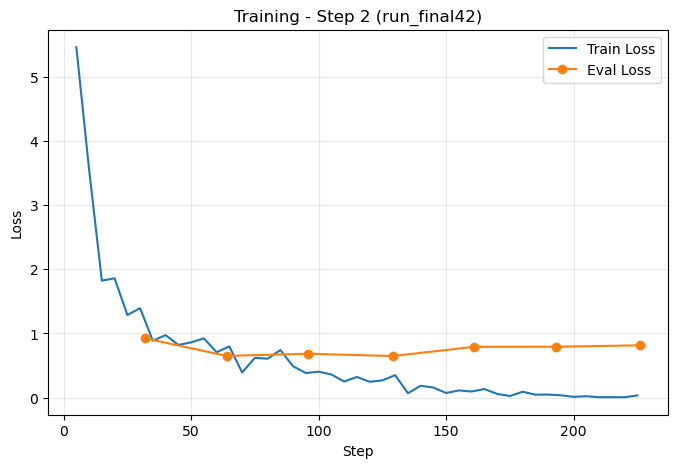

In [41]:
HISTORY_PATH_STEP2 = f"{ADAPTER_DIR}/train_history.json"

if not SKIP_TRAINING:
    # Freshly trained -> use the history directly from the Trainer
    history = trainer_step2.state.log_history

elif os.path.isfile(HISTORY_PATH_STEP2):
    # Existing adapter loaded -> use the previously saved training history
    with open(HISTORY_PATH_STEP2) as f:
        history = json.load(f)

    print(f"Training history loaded from {HISTORY_PATH_STEP2}.")

else:
    # No train_history.json found -> reconstruct the history from the
    # original Trainer output directory and its checkpoints
    history = load_log_history_from_checkpoints(f"isco_step2_{RUN_NAME}")

    if history is not None:
        print(
            f"Training history reconstructed from the Trainer checkpoints "
            f"in 'isco_step2_{RUN_NAME}'."
        )

        # Save the history with the adapter for future use
        with open(HISTORY_PATH_STEP2, "w") as f:
            json.dump(history, f)

        print(
            f"-> Saved as {HISTORY_PATH_STEP2} so it can be loaded directly next time."
        )
    else:
        print(
            f"No training history found (neither {HISTORY_PATH_STEP2} "
            f"nor checkpoints in 'isco_step2_{RUN_NAME}') -> skipping the plot."
        )

if history:
    # Extract training and evaluation loss
    train_loss = [
        (entry["step"], entry["loss"])
        for entry in history
        if "loss" in entry
    ]

    eval_loss = [
        (entry["step"], entry["eval_loss"])
        for entry in history
        if "eval_loss" in entry
    ]

    # Plot training and evaluation loss
    plt.figure(figsize=(8, 5))

    if train_loss:
        train_steps, train_values = zip(*train_loss)
        plt.plot(train_steps, train_values, label="Train Loss")

    if eval_loss:
        eval_steps, eval_values = zip(*eval_loss)
        plt.plot(eval_steps, eval_values, label="Eval Loss", marker="o")

    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(f"Training - Step 2 ({RUN_NAME})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [42]:
def predict_isco_code(row, model, tokenizer, max_new_tokens=6):
    """Generate an ISCO code prediction for a job advertisement."""
    prompt = build_instruction(row)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.2,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode only the newly generated tokens
    generated_ids = output[0][inputs["input_ids"].shape[1]:]
    generated_text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
    )

    return generated_text.strip()

In [43]:
# Create a set of valid 3-digit ISCO codes
valid_codes = set(
    df_isco["isco_code"]
    .astype(str)
    .str.split(".")
    .str[0]
    .str.strip()
    .str.zfill(3)
)


def extract_and_validate_code(generated_text: str, valid_codes: set):
    """Extract and validate a 3-digit ISCO code from model output."""
    if not isinstance(generated_text, str):
        return "INVALID", False

    match = re.search(r"\b\d{3}\b", generated_text)

    if not match:
        return "INVALID", False

    candidate = match.group()
    is_valid = candidate in valid_codes

    return (candidate if is_valid else "INVALID"), is_valid

In [44]:
def evaluate_split(model, tokenizer, df, valid_codes, split_name="eval"):
    """Evaluate ISCO predictions and calculate classification metrics."""
    results = []

    for index, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc=f"Evaluating on {split_name}",
    ):
        generated = predict_isco_code(row, model, tokenizer)
        predicted_code, is_valid = extract_and_validate_code(
            generated,
            valid_codes,
        )

        true_code = (
            str(row["isco"])
            .split(".")[0]
            .strip()
            .zfill(3)
        )

        results.append(
            {
                "job_id": row.get("job_id", index),
                "true_code": true_code,
                "raw_output": generated,
                "predicted_code": predicted_code,
                "is_valid_code": is_valid,
                "true_major": true_code[0] if true_code else "N/A",
                "pred_major": predicted_code[0] if is_valid else "INVALID",
            }
        )

    results_df = pd.DataFrame(results)

    # Create 2-digit ISCO codes for hierarchical evaluation
    results_df["true_2digit"] = results_df["true_code"].str[:2]
    results_df["pred_2digit"] = results_df["predicted_code"].str[:2]

    # Calculate classification metrics
    acc_3 = accuracy_score(
        results_df["true_code"],
        results_df["predicted_code"],
    )
    acc_2 = accuracy_score(
        results_df["true_2digit"],
        results_df["pred_2digit"],
    )
    acc_1 = accuracy_score(
        results_df["true_major"],
        results_df["pred_major"],
    )
    f1 = f1_score(
        results_df["true_code"],
        results_df["predicted_code"],
        average="macro",
        zero_division=0,
    )

    valid_rate = results_df["is_valid_code"].mean()

    # Calculate accuracy only for valid model predictions
    valid_only = results_df[results_df["is_valid_code"]]

    cond_acc = (
        accuracy_score(
            valid_only["true_code"],
            valid_only["predicted_code"],
        )
        if len(valid_only)
        else 0.0
    )

    print(f"--- {split_name.upper()} | {RUN_NAME} ---")
    print(f"Valid Codes Rate:     {valid_rate * 100:.1f}%")
    print(f"3-Digit Exact Acc:    {acc_3 * 100:.1f}%")
    print(f"2-Digit Acc:          {acc_2 * 100:.1f}%")
    print(f"1-Digit (Major) Acc:  {acc_1 * 100:.1f}%")
    print(f"Total Macro F1:       {f1:.3f}")
    print(f"Conditional Accuracy: {cond_acc * 100:.1f}%")

    metrics = {
        "run_name": RUN_NAME,
        "split": split_name,
        "acc_3digit": acc_3,
        "acc_2digit": acc_2,
        "acc_1digit": acc_1,
        "macro_f1": f1,
        "valid_rate": valid_rate,
        "conditional_acc": cond_acc,
    }

    return metrics, results_df


# Evaluate on the evaluation set during model tuning
metrics, results_df = evaluate_split(
    model,
    tokenizer,
    eval_df,
    valid_codes,
    "eval",
)

Evaluating on eval:   0%|          | 0/104 [00:00<?, ?it/s]/opt/conda/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:601: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:606: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
Evaluating on eval: 100%|██████████| 104/104 [00:13<00:00,  7.77it/s]

--- EVAL | run_final42 ---
Valid Codes Rate:     100.0%
3-Digit Exact Acc:    74.0%
2-Digit Acc:          81.7%
1-Digit (Major) Acc:  84.6%
Total Macro F1:       0.673
Conditional Accuracy: 74.0%


In [45]:
# Log the current run in the experiment log
log_run(metrics)

Metrics successfully saved to run_log.csv.


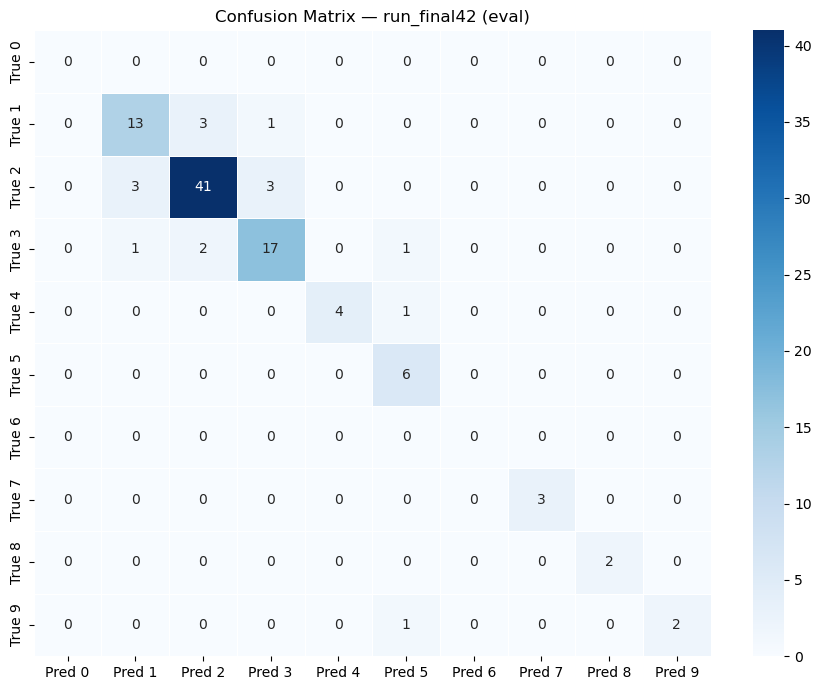

In [46]:
import seaborn as sns
from sklearn.metrics import confusion_matrix


# Create the confusion matrix for the major ISCO groups
major_labels = [str(i) for i in range(10)]

cm = confusion_matrix(
    results_df["true_major"],
    results_df["pred_major"],
    labels=major_labels,
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True {label}" for label in major_labels],
    columns=[f"Pred {label}" for label in major_labels],
)


# Plot and save the confusion matrix
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    linewidths=0.5,
)

plt.title(
    f"Confusion Matrix — {RUN_NAME} ({metrics['split']})",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(
    f"confusion_matrix_{RUN_NAME}.png",
    dpi=300,
)
plt.show()

In [47]:
# Save the trained LoRA adapter and tokenizer
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

if not SKIP_TRAINING:
    # Save the training history so that the loss plot can be reproduced
    # later even when the adapter is only loaded and not retrained.
    import json
    with open(f"{ADAPTER_DIR}/train_history.json", "w") as f:
        json.dump(trainer_step2.state.log_history, f)

    print(f"Adapter and training history saved to {ADAPTER_DIR}.")

In [48]:
# Evaluate and log the final test results after the full training run
if not DEBUG_RUN:
    metrics, results_df = evaluate_split(
        model,
        tokenizer,
        test_df,
        valid_codes,
        "test",
    )

    log_run(metrics)

    # Save the detailed test predictions for later analysis
    results_df.to_csv(
        f"final_test_results_{RUN_NAME}.csv",
        index=False,
    )

Evaluating on test:   0%|          | 0/119 [00:00<?, ?it/s]/opt/conda/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:601: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:606: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
Evaluating on test: 100%|██████████| 119/119 [00:14<00:00,  8.02it/s]

--- TEST | run_final42 ---
Valid Codes Rate:     100.0%
3-Digit Exact Acc:    73.1%
2-Digit Acc:          79.0%
1-Digit (Major) Acc:  84.9%
Total Macro F1:       0.576
Conditional Accuracy: 73.1%
Metrics successfully saved to run_log.csv.


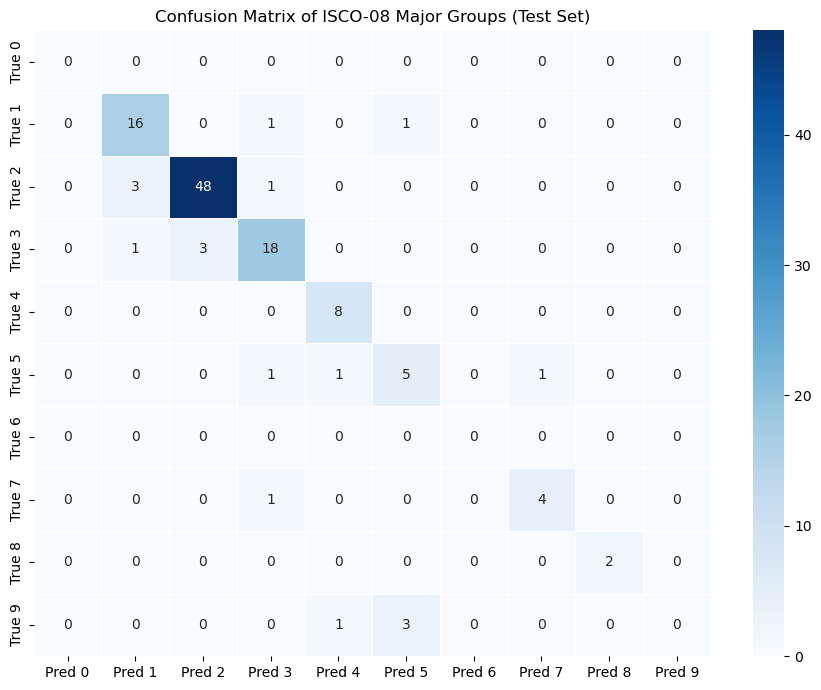

In [49]:
# Load the test results
test_results_df = pd.read_csv(f"final_test_results_{RUN_NAME}.csv")

test_results_df["true_major"] = test_results_df["true_major"].astype(str)
test_results_df["pred_major"] = test_results_df["pred_major"].astype(str)

# Calculate the confusion matrix
major_labels = [str(i) for i in range(10)]
cm_test = confusion_matrix(
    test_results_df["true_major"],
    test_results_df["pred_major"],
    labels=major_labels,
)

cm_test_df = pd.DataFrame(
    cm_test,
    index=[f"True {label}" for label in major_labels],
    columns=[f"Pred {label}" for label in major_labels],
)

# Plot and save the image
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_test_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    linewidths=0.5,
)

plt.title(
    f"Confusion Matrix of ISCO-08 Major Groups (Test Set)",
    fontsize=12,
)
plt.tight_layout()

plt.savefig(
    f"confusion_matrix_test_{RUN_NAME}.png",
    dpi=300,
)
plt.show()

In [50]:
# Calculate the Macro F1 score for 1-digit classification
f1_1digit = f1_score(
    test_results_df["true_major"],
    test_results_df["pred_major"],
    average="macro",
    zero_division=0
)

# Calculate the Macro F1 score for 2-digit classification
f1_2digit = f1_score(
    test_results_df["true_2digit"],
    test_results_df["pred_2digit"],
    average="macro",
    zero_division=0
)

# Calculate the Macro F1 score for 3-digit classification
f1_3digit = f1_score(
    test_results_df["true_code"],
    test_results_df["predicted_code"],
    average="macro",
    zero_division=0
)

# Print the Macro F1 scores for all three classification levels
print(
    f"Macro F1 -- 1-digit: {f1_1digit:.3f} | "
    f"2-digit: {f1_2digit:.3f} | "
    f"3-digit: {f1_3digit:.3f}"
)

Macro F1 -- 1-digit: 0.734 | 2-digit: 0.662 | 3-digit: 0.576
